In [ ]:
import numpy as np
from functools import reduce
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import scipy



# Quantum Reservoir Computing for MNIST Digit Classification using Rydberg Atoms

##  Step 1: Pauli Matrices and Quantum Operators




- Define the Pauli matrices `σ_x`, `σ_z`, identity matrix `I` and number operator `n_i`






In [ ]:
# Pauli X and Z matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

I = np.eye(2, dtype=complex)

# Number operator based on pauli matrices
n_i = (I - sigma_z) / 2


print("sigma_x = \n", sigma_x)
print("sigma_z = \n", sigma_z)
print("n_i = \n", n_i)

sigma_x = 
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
sigma_z = 
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
I = 
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
n_i = 
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


## Step 2: Construct the Rydberg Hamiltonian

The Rydberg Hamiltonian has three parts:

1. **Drive Term**:  
   $$ H_{\text{drive}} = \sum_i \frac{\Omega}{2} \sigma^x_i $$

2. **Detuning Term**:  
   $$ H_{\text{detune}} = -\sum_i \Delta_i \hat{n}_i $$

3. **Interaction Term**:  
   $$ H_{\text{int}} = \sum_{i<j} \frac{C}{|i - j|^6} \hat{n}_i \hat{n}_j $$

- Write the function `rydberg_hamiltonian` to construct the Rydberg Hamiltonian given: 
    **Δ**: detuning,
    **C**: Interaction strength coefficient,
    **Ω**: Rabi frequency,
    **d**: Distance between adjacent atoms. (assume atoms are equally spaced)

In [ ]:
def rydberg_hamiltonian(N, deltas, d, C, Omega):

    # Initialize the Hamiltonian
    H = np.zeros((2**N, 2**N), dtype=complex)

    # drive term
    for i in range(N):
        ops_drive = [I for _ in range(N)]
        ops_drive[i] = sigma_x
        term_drive = reduce(np.kron, ops_drive)
        H += (Omega / 2) * term_drive

    # detuning term
    for i in range(N):
        ops_det = [I for _ in range(N)]
        ops_det[i] = n_i
        term_det = reduce(np.kron, ops_det)
        H += -deltas[i] * term_det

    # create the number operator for each atom
    n_pb = []
    for i in range(N):
        ops_n = [I for _ in range(N)]
        ops_n[i] = n_i
        n_pb.append(reduce(np.kron, ops_n))

    # interaction term
    for i in range(N):
        for j in range(i+1, N):
            if i == j:
                continue
            dist = np.abs(i - j) * d
            term_int = (C / dist**6) * (n_pb[i] @ n_pb[j])
            H += term_int

    return H

# Example 
if __name__ == "__main__":
    N = 2  # atoms
    deltas = [1,4]
    d = 1.0
    C = 0
    Omega =np.pi*2

    H = rydberg_hamiltonian(N, deltas, d, C, Omega)
    print("Rydberg Hamiltonian:")
    print(H)

Rydberg Hamiltonian:
[[ 0.        +0.j  3.14159265+0.j  3.14159265+0.j  0.        +0.j]
 [ 3.14159265+0.j -4.        +0.j  0.        +0.j  3.14159265+0.j]
 [ 3.14159265+0.j  0.        +0.j -1.        +0.j  3.14159265+0.j]
 [ 0.        +0.j  3.14159265+0.j  3.14159265+0.j -5.        +0.j]]


## Step 3: Build Observable Operators

Before we simulate a quantum system, we need to define the **operators** we want to measure later. These are matrix representations of quantum observables, such as single-qubit $ \sigma^z $ or two-qubit correlations like $ \sigma^z_i \sigma^z_j $.

At this stage, we are **not doing any measurement**. We don't have a quantum state or wavefunction yet. we're just constructing the matrix forms of these operators, which will be used later to compute expectation values during simulation.



Build matrices for:
 **Single-qubit** observables: $ \sigma^z_i $  
  → Z on the *i-th* qubit, identity elsewhere.
 **Two-qubit** observables: $ \sigma^z_i \sigma^z_j $  
  → Z on both the *i-th* and *j-th* qubits, identity elsewhere.

For example, in a 4-qubit system:
 $ \sigma^z_1 $ means: `I ⊗ Z ⊗ I ⊗ I`  
 $ \sigma^z_0 \sigma^z_2 $ means: `Z ⊗ I ⊗ Z ⊗ I`



- Write a function `build_observables(N)` that returns:
 A list of $ \sigma^z_i $ for all `i` from `0` to `N-1`
 A list of $ \sigma^z_i \sigma^z_j $ for all pairs `i < j`

These will be used later for computing features from the quantum system.


In [47]:
def build_observables(N):
    pair_ops_list = []
    single_ops_list = []
    

    # Single-qubit part
    for i in range(N):
        ops_single = [I for _ in range(N)]
        ops_single[i] = sigma_z
        single_ops_list.append(reduce(np.kron, ops_single))



    # Qubit pairs (coupling)
    for i in range(N):
        for j in range(i + 1, N):
            ops_pair = [I for _ in range(N)]
            ops_pair[i] = sigma_z
            ops_pair[j] = sigma_z
            pair_ops_list.append(reduce(np.kron, ops_pair))
    
    return single_ops_list + pair_ops_list



In [42]:
# Example usage
if __name__ == "__main__":
    N = 2
    # number of total observalbes:
    total_observables = N + (N * (N - 1)) // 2
    print(f"Expected total number of observables for {N} qubits: {total_observables}")


    total_observables = build_observables(N)
    print(f"Actual number of observables: {len(total_observables)}")
    print("")
    print("Single-qubit operators:")
    for op in total_observables[:N]:
        print(op)
        print("")
    print("Two-qubit operators:")
    for op in total_observables[N:]:
        print(op)

Expected total number of observables for 2 qubits: 3
Actual number of observables: 3

Single-qubit operators:
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j -0.+0.j -1.+0.j]]

[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j -0.+0.j  0.+0.j -1.+0.j]]

Two-qubit operators:
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j -0.+0.j]
 [ 0.+0.j -0.+0.j -0.+0.j  1.-0.j]]


## Step 4: Simulate Quantum Dynamics and Measure Observables

Now that you've built the Hamiltonian and defined your observable operators, it's time to simulate the quantum system's evolution and extract features.

We will:
1. **Initialize** the quantum state to the ground state: $|\psi_0\rangle = |0\rangle^{\otimes N}$

2. **Evolve** the system in time using the unitary operator:
   $$
   U = e^{-i H \Delta t}
   $$

At each time step $ t $, the quantum state is updated as:

$$
|\psi(t + \Delta t)\rangle = U |\psi(t)\rangle
$$
   
3. **At each time step**, compute expectation values of your observables:
   $$
   \langle O \rangle = \langle \psi(t) | O | \psi(t) \rangle
   $$
4. **Collect all measurements** into a single feature vector.


###  You should:
- Write a function `simulate_dynamics(deltas, observables)` that:
  - Constructs the Hamiltonian using your `rydberg_hamiltonian` function.
  - Evolves the system over time (from $t = 0 $ to $ t = 4 $ in steps of $\Delta t = 0.5$).
  - Measures each observable at each time step.
  - Returns a 1D feature vector of all collected measurements.

Tip: Use `torch.matrix_exp()` or `scipy.linalg.expm()` to compute the matrix exponential.



In [45]:
def simulate_dynamics(deltas, observables, t_total=4.0, dt=0.5, d=1.0, C=1.0, Omega=1.0):
   
    N = len(deltas)
    num_steps = int(t_total / dt)

    #Hamiltonian building
    H = rydberg_hamiltonian(N, deltas, d, C, Omega)

    # all qubits initialized in ground state
    initial_state = np.zeros((2**N,1), dtype=complex)
    initial_state[0,0] = 1.0

    # feature list and current state
    feature_vector = []
    state = initial_state.copy()

    # time evolution operator calculation
    U = scipy.linalg.expm(-1j * H * dt)

    # measure observables at each time step and evolve state
    for step in range(num_steps):
        for obser in observables:
            expectation_value = np.vdot(state, np.dot(obser, state)).real
            feature_vector.append(expectation_value)
        # Simulate evolution 
        state = np.dot(U, state)
        # Normalize 
        state = state / np.linalg.norm(state)

    return np.array(feature_vector)



In [46]:
# Example usage
if __name__ == "__main__":
    N = 4
    deltas = np.array([1.0, 2.0,3.0,1.0])
    d = 1.0
    C = 0.0
    Omega = 2 * np.pi

    observables = build_observables(N)
    feature_vector = simulate_dynamics(deltas, observables, t_total=4.0, dt=0.5, d=d, C=C, Omega=Omega)

    print("\nFeature vector from dynamics simulation:")
    print(feature_vector.flatten())
    print("Feature vector length:", len(feature_vector))
    # feature vector consists of: Z_1, Z_2, Z_1*Z_2 (3 * length of 8 = 24)


Feature vector from dynamics simulation:
[ 1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.         -0.94982866 -0.80507084
 -0.58215641 -0.94982866  0.76467936  0.55294884  0.90217449  0.46867715
  0.76467936  0.55294884  0.99695203  0.95654382  0.81914312  0.99695203
  0.9536283   0.8166464   0.99391334  0.78354629  0.9536283   0.8166464
 -0.94373748 -0.71920467 -0.24111647 -0.94373748  0.6787404   0.22755065
  0.89064043  0.17341209  0.6787404   0.22755065  0.98782715  0.83033485
  0.35690452  0.98782715  0.82022732  0.35255998  0.97580249  0.29635026
  0.82022732  0.35255998 -0.93159318 -0.55569131  0.28948213 -0.93159318
  0.51767824 -0.26967958  0.86786586 -0.16086271  0.51767824 -0.26967958
  0.97268242  0.63345361 -0.18140116  0.97268242  0.61614919 -0.17644572
  0.94611109 -0.11490922  0.61614919 -0.17644572 -0.91347168 -0.330182
  0.77396097 -0.91347168  0.30161191 -0.70699143  0.83443052 -0.25554798
  0.30161191 -0.7069

## Step 5: Load and Preprocess the MNIST Dataset

The MNIST dataset contains **60,000 training images** and **10,000 test images** of handwritten digits.

We split this data into:
 A **training set** (used to train the classifier)
 A **test set** (used to evaluate how well the model generalizes)



Before feeding classical data into our quantum system, we need to prepare it in a way that fits the quantum reservoir setup. 

In our case, the goal is to classify handwritten digits. So we must encode the image information into our quantum system in a meaningful way.



In this step, you will:
- Load the MNIST dataset of handwritten digits.
- Flatten each $28 \times 28$ image into a 784-dimensional vector.
- Normalize pixel values to the $[0, 1]$ range.
- Apply **Principal Component Analysis (PCA)** to reduce each image to **8 principal components** — one for each atom in our quantum reservoir.  
  ➤ That is, we have 8 atoms, and each of these 8 numbers will be used as a **detuning** value $\Delta_i$.
- Scale the PCA components to fit the desired experimental detuning range of **$[-6  rad/\mu s, 6  rad/\mu s]$** for the quantum system.



### To do so:
1. Load the MNIST dataset using `torchvision.datasets`.
2. Flatten and normalize the image data.
3. Use `sklearn.decomposition.PCA` to reduce each image to 8 components.
4. Rescale the PCA output so each component lies within $[-6, 6]$, suitable for encoding as detuning parameters ($\Delta_1$ to $\Delta_8$).

Tip: You can divide by the maximum absolute PCA value and multiply by 6 to rescale symmetrically.



### By the end of this step, you should have:

 `x_train_scaled`: the PCA-reduced and rescaled input features for training  
 `x_test_scaled`: the same for the test set  
 `y_train`: the actual digit labels (0–9) for training  
 `y_test`: the labels for the test set


In [14]:
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.utils import shuffle

# Load datasettransform = transforms.ToTensor()
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(type(train_dataset))
print(len(test_dataset))

<class 'torchvision.datasets.mnist.MNIST'>
10000


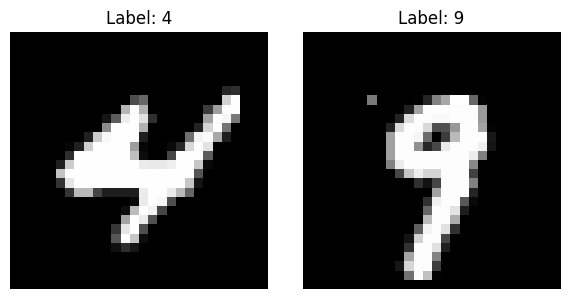

In [ ]:
#just for fun
# Visualization of the mnist dataset 
import random

# Choose 2 random images
indices = random.sample(range(len(train_dataset)), 2)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, idx in zip(axes, indices):
    image, label = train_dataset[idx]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
#  1. normalize that means dividing by 255, since mnist images are grayscale with pixel values in the range 0 to 255
X_train = train_dataset.data.float() / 255.0
X_test = test_dataset.data.float() / 255.0

""" # flatten
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28) """


# 2. Flatten each 28x28 image into a 1D vector of 784 elements
# X_train has shape [num_samples, 28, 28]
# X_train.size(0) gives the number of samples (e.g., 60000)
# The -1 lets PyTorch automatically infer the flattened dimension (28*28 = 784)
X_train_flat = X_train.view(X_train.size(0), -1)

# Same flattening for the test set
X_test_flat = X_test.view(X_test.size(0), -1)


# 3. Princial Component Analysis, 8 components, since we have 8 atoms
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_flat.numpy())
X_test_pca = pca.transform(X_test_flat.numpy())

# scale to [-6, 6] 
X_train_min = X_train_pca.min(axis=0)
X_train_max = X_train_pca.max(axis=0)
X_train_scaled = (X_train_pca - X_train_min) / (X_train_max - X_train_min) * 12 - 6     #you need 12-6 so that its centered around 0 and not from 1 to 12

X_test_min = X_test_pca.min(axis=0)
X_test_max = X_test_pca.max(axis=0)
X_test_scaled = (X_test_pca - X_test_min) / (X_test_max - X_test_min) * 12 - 6

# get labels
y_train = train_dataset.targets
y_test = test_dataset.targets



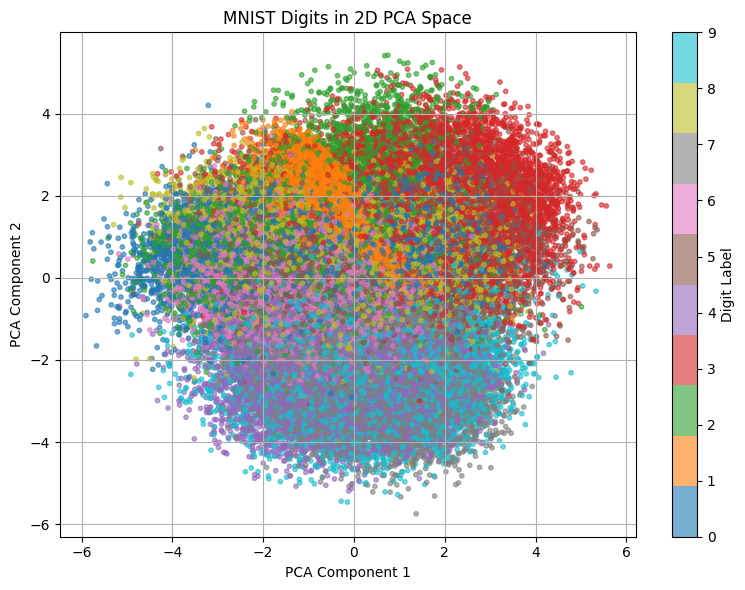

In [ ]:
#just for fun
# Plot to visualize the PCA 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 2], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=10)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("MNIST Digits in 2D PCA Space")
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# reduce training data size (random)
n_train_samples = 1000
n_test_samples = 200

X_train_scaled, y_train = shuffle(X_train_scaled, y_train, random_state=25)
X_train_scaled = X_train_scaled[:n_train_samples]
y_train = y_train[:n_train_samples]

X_test_scaled, y_test = shuffle(X_test_scaled, y_test, random_state=25)
X_test_scaled = X_test_scaled[:n_test_samples]
y_test = y_test[:n_test_samples]

# Print shapes
print("x_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("x_test_scaled shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

x_train_scaled shape: (1000, 8)
y_train shape: torch.Size([1000])
x_test_scaled shape: (200, 8)
y_test shape: torch.Size([200])


## Step 6: Build Quantum Embeddings

In this step, we transform classical input data (PCA-reduced MNIST images) into quantum feature vectors using the quantum reservoir.

This is done by:
- Mapping each 8-dimensional input vector to detuning parameters $[\Delta_1, ..., \Delta_8]$
- Using those to simulate the quantum system with the `simulate_dynamics` function
- Measuring observables at each time step
- Flattening all measurement results into a **288-dimensional feature vector** per image  
  → (8 time steps × 36 observables)



### To do so:
1. Loop through each image in `x_train_scaled` and `x_test_scaled`
2. For each, simulate quantum dynamics and store the corresponding feature vectors.

This step may take some time to run.


In [19]:
#Function for quantum embedding  for 8 quibits for every "image" in the small train and test set, we call the symulate dynamics function, and the deltas are the PCA coponents 


def quantum_embedding(X_scaled, observables, Omega, d, C, t_total=4.0, dt=0.5):
    """
    Generate quantum-inspired feature embeddings for a dataset using quantum dynamics simulation function (earlier defined).

    For each input sanple (e.g., an image represented by its PCA components), this function simulates
    the time evolution of a quantum system (e.g., 8 qubits) under a Hamiltonian determined by input parameters.
    The simulation output is a set of features that encode quantum dynamics corresponding to the input data.

    Parameters:
        X_scaled (ndarray): Input data matrix of shape (num_samples, num_features), e.g., PCA-reduced MNIST data.
        observables (list or ndarray): Observables used to extract features from the quantum system.
        Omega (float): Rabi Frequency.
        d (int):  distance parameter
        C (ndarray): Coupling term for interactions in the quantum system.
        t_total (float): Total simulation time (default: 4.0).
        dt (float): Time step for the simulation (default: 0.5).

    Returns:
        features (list): A list of feature vectors, one per input sample, representing the simulated quantum dynamics.
    """
    # input dimensions
    num_samples = X_scaled.shape[0]
    print(f"Number of samples: {num_samples}, Number of features: {X_scaled.shape[1]}")     

    # features
    features = []

    # loop over each sample (image)
    for i in tqdm(range(num_samples), desc="Quantum Embedding"):
        deltas = X_scaled[i]
        f = simulate_dynamics(deltas, observables, t_total=t_total, dt=dt, d=d, C=C, Omega=Omega)
        features.append(f)
    return features

In [20]:
# Exercise 1 (C=0)
N_atoms = 8
C_1 = 0.0
Omega = 2 * np.pi
d = 10
N_atoms = 8
observables = build_observables(N_atoms)

# QUANTUM EMBEDDINGS FOR EX 1.
X_train_embedded_1 = quantum_embedding(X_train_scaled, observables, Omega, d, C_1)
X_test_embedded_1 = quantum_embedding(X_test_scaled, observables, Omega, d, C_1)


Number of samples: 1000, Number of features: 8


Quantum Embedding: 100%|██████████| 1000/1000 [01:01<00:00, 16.35it/s]


Number of samples: 200, Number of features: 8


Quantum Embedding: 100%|██████████| 200/200 [00:11<00:00, 16.88it/s]


In [21]:
# Exercise 2 (C=1e7))
N_atoms = 8
C_2 = 1e7
Omega = 2 * np.pi
d = 10
N_atoms = 8
observables = build_observables(N_atoms)

# QUANTUM EMBEDDINGS FOR EX 2.
X_train_embedded_2 = quantum_embedding(X_train_scaled, observables, Omega, d, C_2)
X_test_embedded_2 = quantum_embedding(X_test_scaled, observables, Omega, d, C_2)

Number of samples: 1000, Number of features: 8


Quantum Embedding: 100%|██████████| 1000/1000 [00:58<00:00, 17.19it/s]


Number of samples: 200, Number of features: 8


Quantum Embedding: 100%|██████████| 200/200 [00:11<00:00, 16.77it/s]


## Step 7: Train a Linear Classifier

Now that each image is represented by a quantum-derived feature vector, we can train a **simple linear classifier** to predict digit labels (0–9).

We will:
- Define a single-layer neural network **without any hidden layer**(equivalent to logistic regression)
- Use **cross-entropy loss** for classification
- Train using the **Adam optimizer**
- Track accuracy on both training and test sets over epochs



### to do so:
- Implement a PyTorch model with one `nn.Linear` layer
- Define loss function and optimizer
- Train the model over multiple epochs
- Plot accuracy curves to observe learning performance


Set the Rabi frequency to $ \Omega = 2\pi\,\text{MHz} $ and the spacing to $ d = 10\,\mu\text{m} $. 

 **Exercise 1:** Set `C = 0` . Train the classifier and report test accuracy.
 
 **Exercise 2:** Set `C ` to a realistic value (considering the value and dimension of the rest of the parameters). Train again and compare performance. Can you explain the reason compared to Exercise 2?
 
 **Exercise 3:** Train a classifier directly on the PCA components (skip quantum simulation). 
 
 **Exercise 4:** Train a 4-layer feedforward neural network on PCA features. Compare the result of these 3 different approaches (QRC, PCA+linear layer, PCA+4-Layer FFNN)




## Preparations


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [81]:
# Linear Classifier class input dim is 288 because thats the vector of one image (=8(quibits)*36(measurements)) 10 bc we need it to be a number between 0 and 9
class LinearClassifier(nn.Module):
    def __init__(self, input_dim=288, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)  

In [84]:
# 4 Layer Neural Net class with Leaky relu activation function
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [80]:
# function to train the classifier
def train_classifier(model, X_train, y_train, X_test, y_test, num_epochs = 50, lr = 0.001, patience=100):
    model = model.to(device)

    # validation set to test performance while training 10% of the test dataset
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=25, stratify=y_train)

    # mini batches faster
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)        # combines X and y into one dataset
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)          #batches of 32 samples and shuffles them

    #Hyperparameters & early stopping 
    loss_function = nn.CrossEntropyLoss()       #given 
    optimizer = optim.Adam(model.parameters(), lr=lr)       #given
    train_accs, val_accs = [], []
    best_val_acc = 0
    best_epoch = 0

    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)       #moves to GPU if available
            optimizer.zero_grad()       #sets gradient to zero before starting a new batch
            outputs = model(X_batch)        #actually calls the neural net
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()       #Adds this batch’s loss to the total for the epoch.
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()      #compares predicted class to actuall class 
            total += y_batch.size(0)
        epoch_loss /= len(train_loader)
        train_acc = correct / total
        train_accs.append(train_acc)    #Appends accuracy to the list for plotting later.
        
        with torch.no_grad():
            model.eval()
            val_pred = model(X_val).argmax(dim=1)
            val_acc = (val_pred == y_val).float().mean().item()
            val_accs.append(val_acc)

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
        elif epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break
    # test accuracy
    test_pred = model(X_test.to(device)).argmax(dim=1)
    final_test_acc = (test_pred == y_test.to(device)).float().mean().item()

        
        
    return train_accs, val_accs, final_test_acc


In [75]:
def plot_accuracy(train_acc, val_acc, title):
    plt.figure(figsize=(7, 5))
    epochs = range(1, len(train_acc) + 1)
    plt.plot(epochs, train_acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [76]:
def plot_accuracy2_in_1(train_acc_1, val_acc_1,train_acc_2, val_acc_2, title):
    plt.figure(figsize=(7, 5))
    epochs = range(1, len(train_acc_1) + 1)
    epochs2= range(1, len(train_acc_2) + 1)
    plt.plot(epochs, train_acc_1, label='Training Accuracy Ex. 4')
    plt.plot(epochs, val_acc_1, label='Validation Accuracy Ex. 4')
    plt.plot(epochs2, train_acc_2, label='Training Accuracy Ex. 3')
    plt.plot(epochs2,val_acc_2, label='Validation Accuracy Ex. 3')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
#just for fun
import matplotlib.pyplot as plt
from matplotlib import rcParams

def plot_accuracy2_in_1(train_acc_1, val_acc_1, train_acc_2, val_acc_2, title):
    # Use serif font
    rcParams['font.family'] = 'serif'

    plt.figure(figsize=(12, 6))
    epochs_1 = range(1, len(train_acc_1) + 1)
    epochs_2 = range(1, len(train_acc_2) + 1)

    # Plot lines with different colors
    plt.plot(epochs_1, train_acc_1, linestyle='-', linewidth=2, label='Training Accuracy (Experiment 4)', color='#1f77b4')
    plt.plot(epochs_1, val_acc_1, linestyle='--', linewidth=2, label='Validation Accuracy (Experiment 4)', color='#ff7f0e')
    plt.plot(epochs_2, train_acc_2, linestyle='-', linewidth=2, label='Training Accuracy (Experiment 3)', color='#2ca02c')
    plt.plot(epochs_2, val_acc_2, linestyle='--', linewidth=2, label='Validation Accuracy (Experiment 3)', color='#d62728')

    # Labels and formatting
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=11, loc='lower right')
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    plt.tight_layout()
    plt.show()


**Preparations with Simplified Neural Network architecture**

In [27]:
import torch
import torch.nn as nn

input_dim = 288
num_classes = 10

model = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.LeakyReLU(),
    nn.Linear(128, 64),
    nn.LeakyReLU(),
    nn.Linear(64, 32),
    nn.LeakyReLU(),
    nn.Linear(32, num_classes)
).to(device)


## Exercise 1: Quantum Embedding (C=0)

/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/2902322755.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  X_train_torch_1 = torch.tensor(X_train_embedded_1, dtype=torch.float32)
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/2902322755.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_torch_1 = torch.tensor(y_train, dtype=torch.long)
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/2902322755.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().

Early stopping at epoch 160


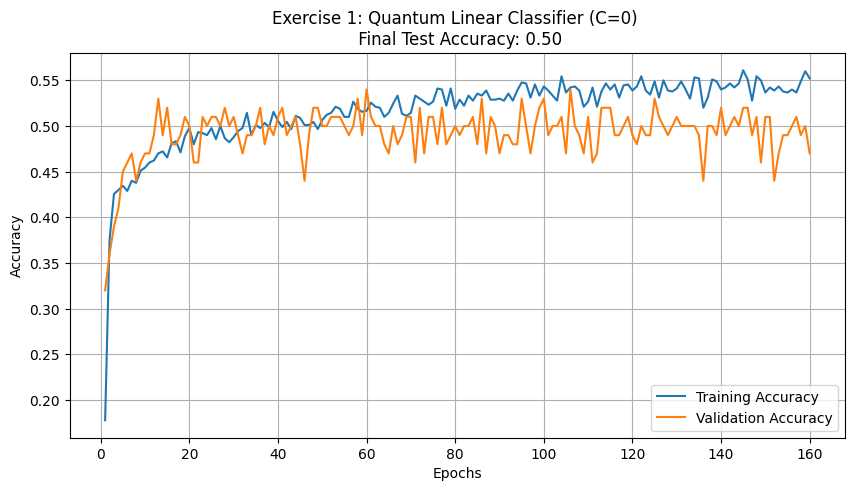

In [ ]:
# convert data to torch tensors
X_train_torch_1 = torch.tensor(X_train_embedded_1, dtype=torch.float32)
y_train_torch_1 = torch.tensor(y_train, dtype=torch.long)
X_test_torch_1 = torch.tensor(X_test_embedded_1, dtype=torch.float32)
y_test_torch_1 = torch.tensor(y_test, dtype=torch.long)

# train the model
model_1 = LinearClassifier(input_dim=X_train_torch_1.shape[1])
train_acc_1, val_acc_1, test_acc_1 = train_classifier(
    model_1,
    X_train_torch_1.to(device),
    y_train_torch_1.to(device),
    X_test_torch_1.to(device),
    y_test_torch_1.to(device),
    num_epochs=1000,
    lr=0.001
)

# Plot the accuracy
plot_accuracy(train_acc_1, val_acc_1, "Exercise 1: Quantum Linear Classifier (C=0) \n  Test Accuracy: {:.2f}".format(test_acc_1))


/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/2699226230.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_torch_2 = torch.tensor(y_train, dtype=torch.long)
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/2699226230.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_torch_2 = torch.tensor(y_test, dtype=torch.long)
Training:  24%|██▍       | 488/2000 [00:07<00:24, 61.21it/s]


Early stopping at epoch 489


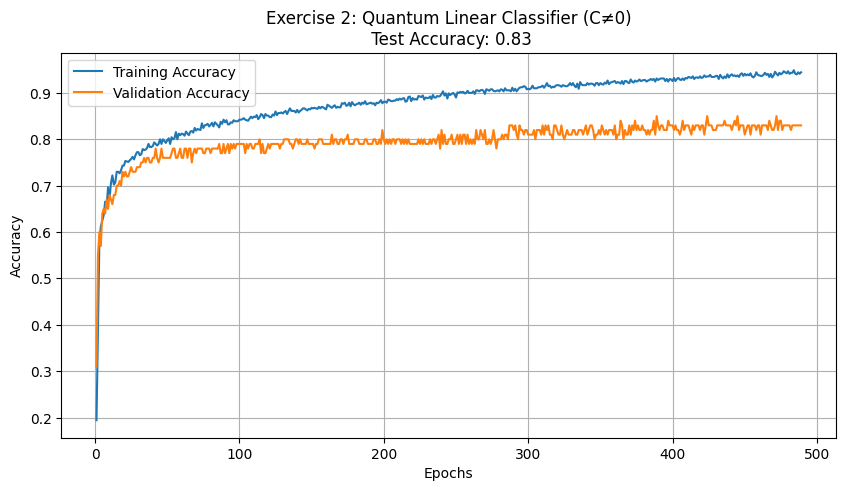

In [ ]:
#just for fun
# Exercise 2: Quantum classifier with realistic C ≠ 0

# Convert quantum features to tensors
X_train_torch_2 = torch.tensor(X_train_embedded_2, dtype=torch.float32)
y_train_torch_2 = torch.tensor(y_train, dtype=torch.long)
X_test_torch_2 = torch.tensor(X_test_embedded_2, dtype=torch.float32)
y_test_torch_2 = torch.tensor(y_test, dtype=torch.long)

# Define and train the linear model
model_2 = LinearClassifier(input_dim=X_train_torch_2.shape[1])
train_acc_2, val_acc_2, test_acc_2 = train_classifier(
    model_2,
    X_train_torch_2.to(device),
    y_train_torch_2.to(device),
    X_test_torch_2.to(device),
    y_test_torch_2.to(device),
    num_epochs=2000,
    lr=0.001
)

# Plot accuracy
plot_accuracy(
    train_acc_2,
    val_acc_2,
    "Exercise 2: Quantum Linear Classifier (C≠0)\n Test Accuracy: {:.2f}".format(test_acc_2)
)


## Exercise 2: Quantum Embedding (C has a realistic value)

This cell:

Prepares quantum-derived features,

Trains a simple linear model,

Tracks and visualizes performance,

Is a clean implementation of Exercise 2 (QRC with coupling).

/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/371536106.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_torch_2 = torch.tensor(y_train, dtype=torch.long)       #training labels also need to be converted
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/371536106.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_torch_2 = torch.tensor(y_test, dtype=torch.long)
Training:  19%|█▉        | 376/2000 [00:04<00:20, 78.64it/s]

Early stopping at epoch 377


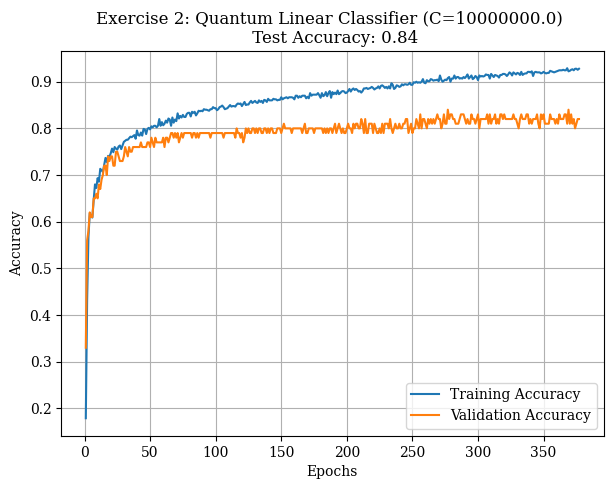

<Figure size 640x480 with 0 Axes>

In [82]:
# convert training quantum features to torch tensors necessary for traininig a neural network
X_train_torch_2 = torch.tensor(X_train_embedded_2, dtype=torch.float32)
y_train_torch_2 = torch.tensor(y_train, dtype=torch.long)       #training labels also need to be converted
X_test_torch_2 = torch.tensor(X_test_embedded_2, dtype=torch.float32)
y_test_torch_2 = torch.tensor(y_test, dtype=torch.long)

# train the model
model_2 = LinearClassifier(input_dim=X_train_torch_2.shape[1])      #input dim needs to be 288 equal to the "size" of the image
train_acc_2, val_acc_2, test_acc_2 = train_classifier(
    model_2,
    X_train_torch_2.to(device),
    y_train_torch_2.to(device),
    X_test_torch_2.to(device),
    y_test_torch_2.to(device),
    num_epochs=2000,
    lr=0.001
)

# Plot the accuracy
plot_accuracy(train_acc_2, val_acc_2, f"Exercise 2: Quantum Linear Classifier (C={C_2}) \n Test Accuracy: {test_acc_2:.2f}")
plt.savefig("c_realistic.pdf")

## Exercise 3: Linear Classifier on PCA Data

In this exercise we are training directly on the PCA component, (the 8 dim latent space) without using the quantum embeddings

In [31]:
# prepare dataset for the PCA based predictions
X_train_torch_pca= torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_torch_pca = y_train.clone().detach().long()

X_test_torch_pca = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_torch_pca = y_test.clone().detach().long()

Training:  14%|█▍        | 141/1000 [00:01<00:08, 104.17it/s]

Early stopping at epoch 142


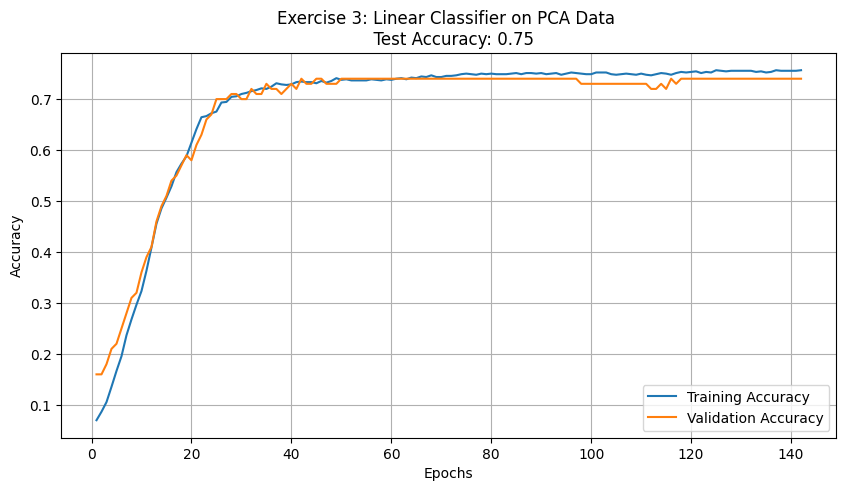

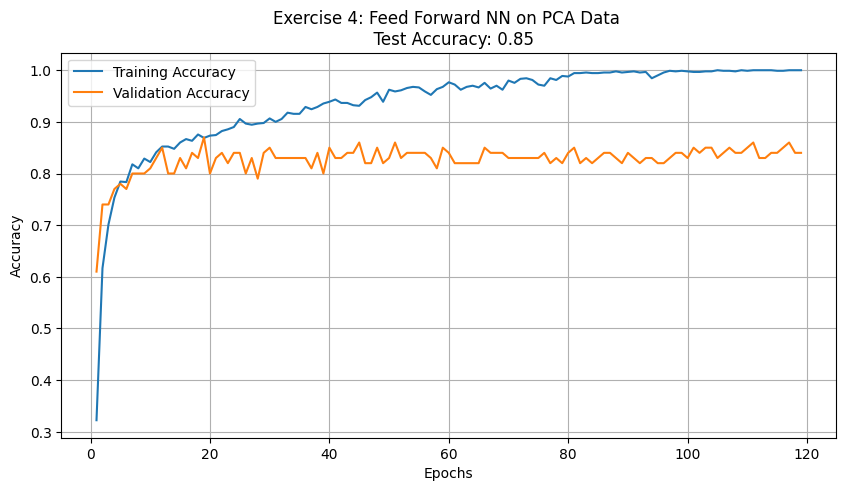

In [ ]:
# Train the Linear Classifier and plot accuracies for the PCA based predictions
model_3 = LinearClassifier(input_dim=X_train_torch_pca.shape[1])

train_acc_3, val_acc_3, test_acc_3 = train_classifier(
    model_3,
    X_train_torch_pca.to(device),
    y_train_torch_pca.to(device),
    X_test_torch_pca.to(device),
    y_test_torch_pca.to(device),
    num_epochs=1000,
    lr=0.001
)
plot_accuracy(train_acc_3, val_acc_3, title=f"Exercise 3: Linear Classifier on PCA Data \n  Test Accuracy: {test_acc_3:.2f}")


## Exercise 4: Feed Forward NN on PCA Data

Training:  24%|██▍       | 120/500 [00:02<00:06, 57.16it/s]


Early stopping at epoch 121


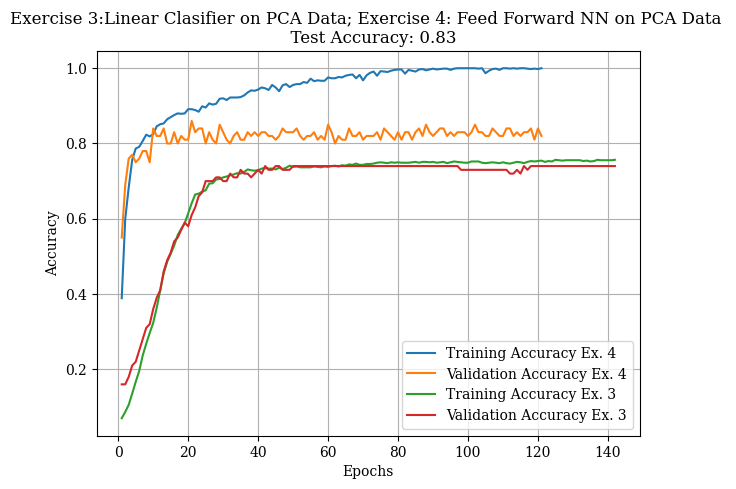

In [87]:
# Train the Feed Forward NN and plot accuracies for the PCA based predictions
model_4 = FeedForwardNN(input_dim=X_train_torch_pca.shape[1])

train_acc_4, val_acc_4, test_acc_4 = train_classifier(
    model_4,
    X_train_torch_pca.to(device),
    y_train_torch_pca.to(device),
    X_test_torch_pca.to(device),
    y_test_torch_pca.to(device),
    num_epochs=500,
    lr=0.001
)
plot_accuracy2_in_1(train_acc_4, val_acc_4, train_acc_3, val_acc_3, title=f"Exercise 3:Linear Clasifier on PCA Data; Exercise 4: Feed Forward NN on PCA Data \n  Test Accuracy: {test_acc_4:.2f}")

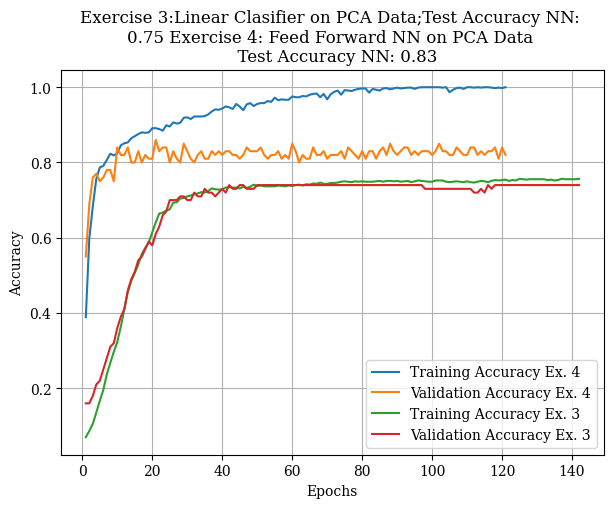

In [88]:
plot_accuracy2_in_1(train_acc_4, val_acc_4, train_acc_3, val_acc_3, title=f"Exercise 3:Linear Clasifier on PCA Data;Test Accuracy NN: \n{test_acc_3:.2f} Exercise 4: Feed Forward NN on PCA Data \n  Test Accuracy NN: {test_acc_4:.2f}")

**Hyperparameter Optimization using Optuna**
not asked just for fun


In [89]:
#just for fun
import optuna

def objective(trial):
    # Suggest hyperparameters
    hidden1 = trial.suggest_int("hidden1", 32, 256)
    hidden2 = trial.suggest_int("hidden2", 16, 128)
    hidden3 = trial.suggest_int("hidden3", 8, 64)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)

    # Define model using nn.Sequential for flexibility
    model = nn.Sequential(
        nn.Linear(X_train_torch_pca.shape[1], hidden1),
        nn.LeakyReLU(),
        nn.Linear(hidden1, hidden2),
        nn.LeakyReLU(),
        nn.Linear(hidden2, hidden3),
        nn.LeakyReLU(),
        nn.Linear(hidden3, 10)
    ).to(device)

    # Train model
    train_acc, val_acc, test_acc = train_classifier(
        model,
        X_train_torch_pca.to(device),
        y_train_torch_pca.to(device),
        X_test_torch_pca.to(device),
        y_test_torch_pca.to(device),
        num_epochs=300,
        lr=lr
    )

    # Optuna will maximize validation accuracy from the final epoch
    return val_acc[-1]

# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Best hyperparameters
print("Best trial:")
print(study.best_trial)


[I 2025-06-13 16:56:27,691] A new study created in memory with name: no-name-a1efecc7-e42d-410a-81da-43ca61e768f0
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
Training:  73%|███████▎  | 218/300 [00:04<00:01, 49.81it/s]
[I 2025-06-13 16:56:32,090] Trial 0 finished with value: 0.8799999952316284 and parameters: {'hidden1': 247, 'hidden2': 83, 'hidden3': 56, 'lr': 0.00393362765254711}. Best is trial 0 with value: 0.8799999952316284.
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=Tr

Early stopping at epoch 219


Training:  40%|███▉      | 119/300 [00:02<00:03, 49.54it/s]
[I 2025-06-13 16:56:34,496] Trial 1 finished with value: 0.8399999737739563 and parameters: {'hidden1': 188, 'hidden2': 103, 'hidden3': 31, 'lr': 0.0017350913917872986}. Best is trial 0 with value: 0.8799999952316284.
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Early stopping at epoch 120


Training:  63%|██████▎   | 188/300 [00:03<00:02, 51.80it/s]
[I 2025-06-13 16:56:38,129] Trial 2 finished with value: 0.8299999833106995 and parameters: {'hidden1': 189, 'hidden2': 123, 'hidden3': 12, 'lr': 0.00027871443401397136}. Best is trial 0 with value: 0.8799999952316284.
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


...

Early stopping at epoch 149


Training:  51%|█████     | 153/300 [00:03<00:03, 46.92it/s]
[I 2025-06-13 16:57:15,146] Trial 15 finished with value: 0.8299999833106995 and parameters: {'hidden1': 225, 'hidden2': 104, 'hidden3': 39, 'lr': 0.009195569587340939}. Best is trial 0 with value: 0.8799999952316284.
/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Early stopping at epoch 154


Training:  18%|█▊        | 54/300 [00:01<00:04, 51.51it/s]
[W 2025-06-13 16:57:16,205] Trial 16 failed with parameters: {'hidden1': 168, 'hidden2': 75, 'hidden3': 64, 'lr': 0.0012627476077265059} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/moriheidtmann/Documents/AI_Test/qcml/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/1352900589.py", line 23, in objective
    train_acc, val_acc, test_acc = train_classifier(
                                   ^^^^^^^^^^^^^^^^^
  File "/var/folders/y4/fm66k2316xs_b3mz5_kr31yc0000gn/T/ipykernel_38425/3060432048.py", line 29, in train_classifier
    loss.backward()
  File "/Users/moriheidtmann/Documents/AI_Test/qcml/.venv/lib/python3.12/site-packages/torch/_tensor.py", line 648, in backward
    torch.autograd.backwar

KeyboardInterrupt: 

Training:  40%|████      | 121/300 [00:02<00:03, 45.90it/s]

Early stopping at epoch 122


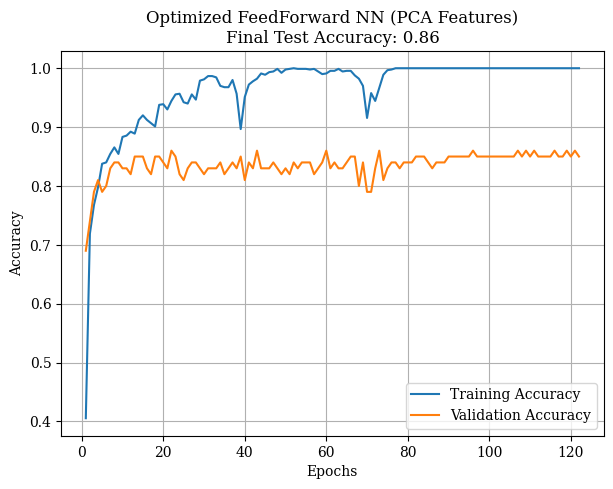

In [ ]:
# Extract best hyperparameters from the Optuna study
best_params = study.best_trial.params

# Build model using best hyperparameters
model_opt = nn.Sequential(
    nn.Linear(X_train_torch_pca.shape[1], best_params["hidden1"]),
    nn.LeakyReLU(),
    nn.Linear(best_params["hidden1"], best_params["hidden2"]),
    nn.LeakyReLU(),
    nn.Linear(best_params["hidden2"], best_params["hidden3"]),
    nn.LeakyReLU(),
    nn.Linear(best_params["hidden3"], 10)
).to(device)

# Retrain using the best learning rate
train_acc_opt, val_acc_opt, test_acc_opt = train_classifier(
    model_opt,
    X_train_torch_pca.to(device),
    y_train_torch_pca.to(device),
    X_test_torch_pca.to(device),
    y_test_torch_pca.to(device),
    num_epochs=300,
    lr=best_params["lr"]
)

# Plot the results
plot_accuracy(
    train_acc_opt,
    val_acc_opt,
    title=f"Optimized FeedForward NN (PCA Features)\nFinal Test Accuracy: {test_acc_opt:.2f}"
)
